<a href="https://colab.research.google.com/github/shahankit82/ml-assessment-Ankit-Shah/blob/main/Part_a/q1_supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1 Supervised Learning - Heart Disease Classification

Beginner-friendly step-by-step notebook.

## 1. Data Loading and Inspection

In [9]:
import pandas as pd

# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/shahankit82/ml-assessment-Ankit-Shah/refs/heads/main/Data/q1_heart_disease.csv')

# Shape
print("Shape:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# First 5 rows
df.head()

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2. Exploratory Data Analysis

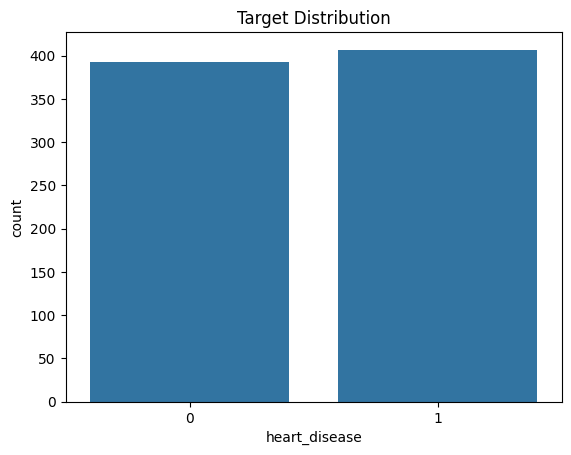

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
sns.countplot(x='heart_disease', data=df)
plt.title("Target Distribution")
plt.show()

This shows how many patients have heart disease vs not.

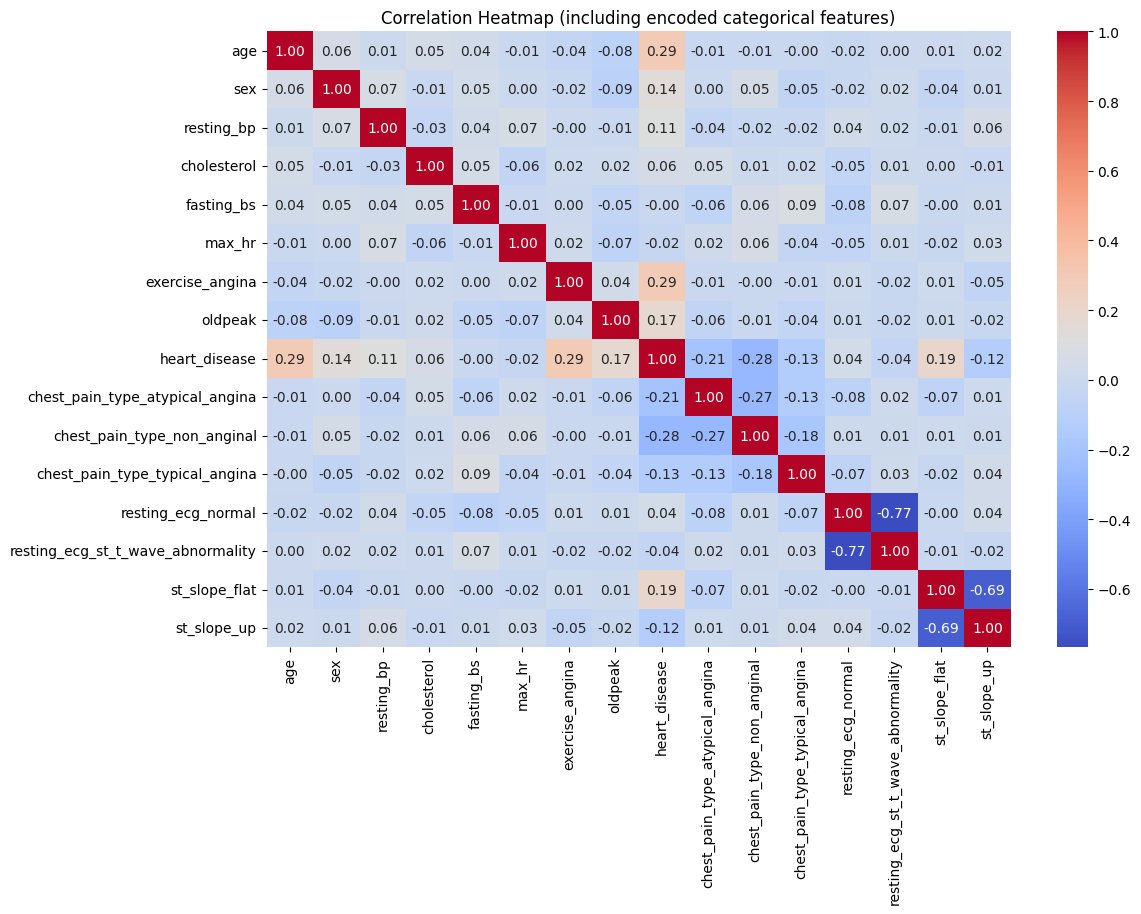

In [11]:
import numpy as np # Import numpy for numeric_only=True

# Correlation heatmap
plt.figure(figsize=(12,8))

# Create a temporary DataFrame for correlation calculation
df_temp = df.copy()

# First, handle missing values (as done in preprocessing section)
df_temp = df_temp.fillna(df_temp.median(numeric_only=True))

# Then, perform one-hot encoding on categorical columns
df_temp = pd.get_dummies(df_temp, drop_first=True)

sns.heatmap(df_temp.corr(), annot=True, cmap='coolwarm', fmt=".2f") # Added fmt for better readability
plt.title("Correlation Heatmap (including encoded categorical features)")
plt.show()

This shows relationships between variables.

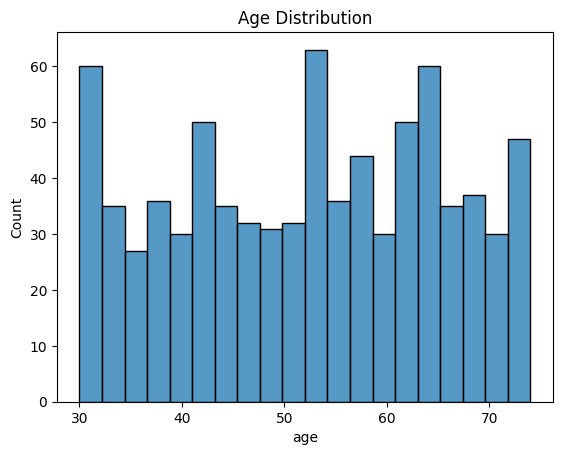

In [12]:
# Age distribution
sns.histplot(df['age'], bins=20)
plt.title("Age Distribution")
plt.show()

This shows how ages are spread in the dataset.

## 3. Data Preprocessing

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Handle missing values (median)
df = df.fillna(df.median(numeric_only=True))

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Model Training

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Train
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

## 5. Model Evaluation

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

models = {'Decision Tree': dt, 'Random Forest': rf, 'Gradient Boosting': gb}

for name, model in models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Decision Tree
Confusion Matrix:
 [[67 31]
 [36 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.68      0.67        98
           1       0.68      0.65      0.66       102

    accuracy                           0.67       200
   macro avg       0.67      0.67      0.66       200
weighted avg       0.67      0.67      0.66       200


Random Forest
Confusion Matrix:
 [[77 21]
 [17 85]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.80        98
           1       0.80      0.83      0.82       102

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200


Gradient Boosting
Confusion Matrix:
 [[74 24]
 [20 82]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.76      0.77        98
  

Compare precision, recall, and F1-score to decide best model.

## 6. Hyperparameter Tuning

In [16]:
from sklearn.model_selection import GridSearchCV

# Example tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Evaluate tuned model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\nTuned Model Performance")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Parameters: {'max_depth': None, 'n_estimators': 100}

Tuned Model Performance
[[77 21]
 [17 85]]
              precision    recall  f1-score   support

           0       0.82      0.79      0.80        98
           1       0.80      0.83      0.82       102

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200

